In [18]:
# 导入必备工具包
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# 获取标签数量分布

                                            sentence  label
0   早餐不好,服务不到位,晚餐无西餐,早餐晚餐相同,房间条件不好,餐厅不分吸烟区.房间不分有无烟房.      0
1  去的时候 ,酒店大厅和餐厅在装修,感觉大厅有点挤.由于餐厅装修本来该享受的早饭,也没有享受(...      1
2  有很长时间没有在西藏大厦住了，以前去北京在这里住的较多。这次住进来发现换了液晶电视，但网络不...      1
3  非常好的地理位置，住的是豪华海景房，打开窗户就可以看见栈桥和海景。记得很早以前也住过，现在重...      1
4            交通很方便，房间小了一点，但是干净整洁，很有香港的特色，性价比较高，推荐一下哦      1
5               酒店的装修比较陈旧，房间的隔音，主要是卫生间的隔音非常差，只能算是一般的      0
6  酒店有点旧，房间比较小，但酒店的位子不错，就在海边，可以直接去游泳。8楼的海景打开窗户就是海...      1
7  位置很好，走路到文庙、清凉寺5分钟都用不了，周边公交车很多很方便，就是出租车不太爱去（老城区...      1
8                           酒店设备一般，套房里卧室的不能上网，要到客厅去。      0


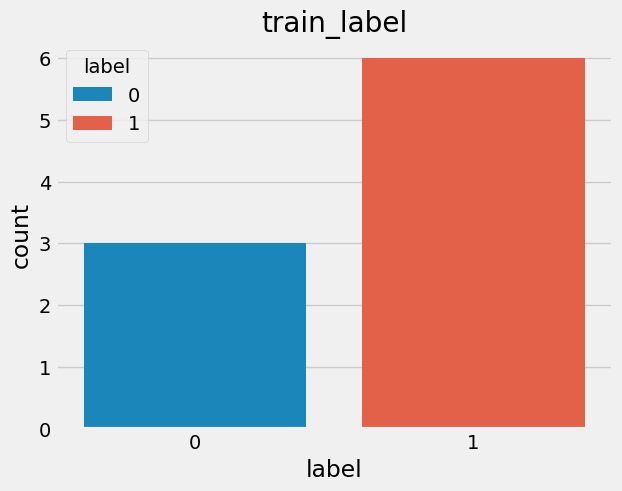

In [21]:
# 1 设置显示风格plt.style.use('fivethirtyeight')
plt.style.use("fivethirtyeight")

train_data = pd.read_csv("assets/train.tsv", sep="|")
print(train_data)
# print(train_data["sentence"])
# 3 sns.countplot() 统计label标签的0、1分组数量
sns.countplot(x="label", data=train_data, hue="label")

# 4 画图展示 plt.title() plt.show()
plt.title("train_label")
plt.show()

# 获取句子长度分布

- 思路分析 : 获取句子长度分布 -绘制句子长度分布-柱状图 句子长度分布-密度曲线图
- 0 什么是句子长度分布：求长度为50的有多少个 长度51的有多少个 长度为52的有多少个
- 1 设置显示风格plt.style.use('fivethirtyeight')
- 2 pd.read_csv(path, sep='\t') 读训练集 验证集数据
- 3 新增数据长度列：train_data['sentence_length'] = list(map(lambda x:len(x) , ...))
- 4-1 绘制数据长度分布图-柱状图 sns.countplot(x='sentence_length', data=train_data)
-  画图展示 plt.xticks([]) plt.show()
- 4-2  绘制数据长度分布图-曲线图 sns.displot(x='sentence_length', data=train_data)
- 画图展示 plt.yticks([]) plt.show()


                                            sentence  label  sentence_length
0   早餐不好,服务不到位,晚餐无西餐,早餐晚餐相同,房间条件不好,餐厅不分吸烟区.房间不分有无烟房.      0               48
1  去的时候 ,酒店大厅和餐厅在装修,感觉大厅有点挤.由于餐厅装修本来该享受的早饭,也没有享受(...      1               80
2  有很长时间没有在西藏大厦住了，以前去北京在这里住的较多。这次住进来发现换了液晶电视，但网络不...      1               69
3  非常好的地理位置，住的是豪华海景房，打开窗户就可以看见栈桥和海景。记得很早以前也住过，现在重...      1               65
4            交通很方便，房间小了一点，但是干净整洁，很有香港的特色，性价比较高，推荐一下哦      1               39
5               酒店的装修比较陈旧，房间的隔音，主要是卫生间的隔音非常差，只能算是一般的      0               36
6  酒店有点旧，房间比较小，但酒店的位子不错，就在海边，可以直接去游泳。8楼的海景打开窗户就是海...      1              105
7  位置很好，走路到文庙、清凉寺5分钟都用不了，周边公交车很多很方便，就是出租车不太爱去（老城区...      1               68
8                           酒店设备一般，套房里卧室的不能上网，要到客厅去。      0               24


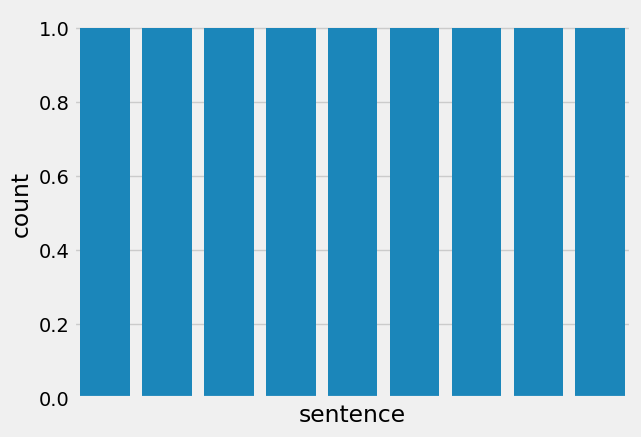

d:\my code\deeplearning\.venv\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


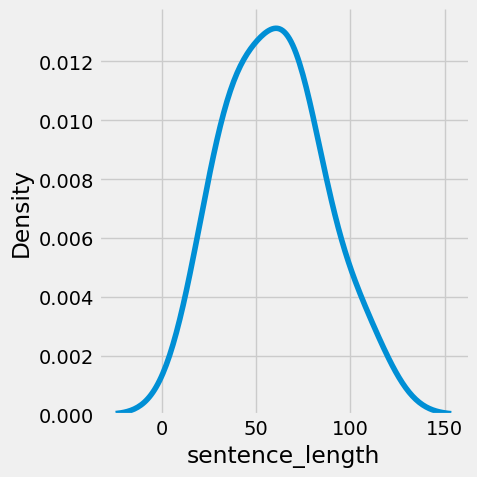

In [ ]:
# 先求出数据长度
getLen = lambda x: len(x)
train_data["sentence_length"] = list(map(getLen, train_data["sentence"]))
print(train_data)

# 绘制数据长度分布图 - 柱状图
sns.countplot(x="sentence", data=train_data)
plt.xticks([])
plt.show()

# 核密度图：通过核密度图可以比较直观地看出数据样本本身的分布特征
sns.displot(x="sentence_length", data=train_data, kind="kde")
# plt.yticks([])  # y轴上不要提示信息
plt.show()

# 获取正负样本长度散点分布

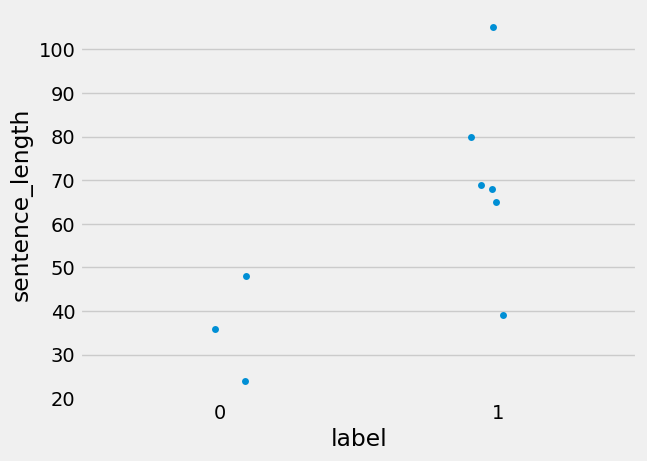

In [39]:

sns.stripplot(x="label", y="sentence_length", data=train_data)
plt.show()

 # 获取不同词汇总数统计

In [41]:
import jieba
from itertools import chain

# 进行训练集的句子进行分词, 并统计出不同词汇的总数
# set进行去重
train_vocab = set(chain(*map(lambda x: jieba.lcut(x), train_data["sentence"])))
print("训练集共包含不同词汇总数为：", len(train_vocab))

训练集共包含不同词汇总数为： 189


# n-gram特征

![ngram.png](./assets/images/ngram.png)
